In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy import stats
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.tokenize import word_tokenize
# Error:
"""
LookupError: 
**********************************************************************
  Resource punkt not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load tokenizers/punkt/english.pickle

  Searched in:
    - 'C:\\Users\\krita/nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\share\\nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\lib\\nltk_data'
    - 'C:\\Users\\krita\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
    - ''
**********************************************************************
"""
# Source - https://stackoverflow.com/a
# Posted by alok, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-07, License - CC BY-SA 4.0
# nltk.download('punkt')
# nltk.download('wordnet')
# nltk.download('omw-1.4')

# Error:
"""
LookupError: 
**********************************************************************
  Resource stopwords not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('stopwords')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load corpora/stopwords

  Searched in:
    - 'C:\\Users\\krita/nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\share\\nltk_data'
    - 'D:\\Y3S1 Applied Machine Learning(Retake)\\Workspace\\AML_Retake\\lib\\nltk_data'
    - 'C:\\Users\\krita\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************
"""
# nltk.download("stopwords")

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

In [2]:
df = pd.read_csv("spam_mail.csv")

In [3]:
df.head()

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.info

<bound method DataFrame.info of      Category                                           Masseges
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham              Will Ì_ b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name

[5572 rows x 2 columns]>

In [5]:
df.nunique

<bound method DataFrame.nunique of      Category                                           Masseges
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham              Will Ì_ b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name

[5572 rows x 2 columns]>

In [6]:
df.isnull().sum()

Category    0
Masseges    0
dtype: int64

In [7]:
# Correcting the 'Masseges' typo
df.rename(columns={'Masseges': 'Messages'}, inplace=True)
df

,Category,Messages
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [8]:
df['message_length'] = df['Messages'].apply(lambda x: len(x))
df.head()                                             

,Category,Messages,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [9]:
# preprocessing functions

def search_urls(text):
    return len(re.findall(r'https?://\S+|www\.\S+', text))
    
def search_emails(text):
    return len(re.findall(r'\S+@\S+', text)) 

def convert_to_lowercase(text):
    return text.lower()

def remove_numbers(text):
    return re.sub(r'\d+', '', text)

def remove_punctuation(text):
    return re.sub(r'[^\w\s]', '', text)

def remove_extra_white_spaces(text):
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def remove_stopwords(text):
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_words = [word 
                      for word in tokens if word not in stop_words]
    return " ".join(filtered_words)

def lemmatize_words(text):
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)
    lemmatized_words = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(lemmatized_words)

# Function to correct spellings and typos

In [10]:
# Since emails and urls are a strong indicators for spam mail,
# features url_count and email_count are introduced.
df['url_count'] = df['Messages'].apply(lambda x: search_urls(x))
df['email_count'] = df['Messages'].apply(lambda x: search_emails(x))

In [11]:
# Applying preprocessing functions to Messages
df['Messages'] = df['Messages'].apply(lambda x: convert_to_lowercase(x))
df['Messages'] = df['Messages'].apply(lambda x: remove_numbers(x))
df['Messages'] = df['Messages'].apply(lambda x: remove_punctuation(x))
df['Messages'] = df['Messages'].apply(lambda x: remove_extra_white_spaces(x))
df['Messages'] = df['Messages'].apply(lambda x: remove_stopwords(x))
df['Messages'] = df['Messages'].apply(lambda x: lemmatize_words(x))

In [12]:
df['message_length_after_preprocessing'] = df['Messages'].apply(lambda x: len(x))
df.head(20)    

,Category,Messages,message_length,url_count,email_count,message_length_after_preprocessing
0,ham,go jurong point crazy available bugis n great ...,111,0,0,82
1,ham,ok lar joking wif u oni,29,0,0,23
2,spam,free entry wkly comp win fa cup final tkts st ...,155,0,0,106
3,ham,u dun say early hor u c already say,49,0,0,35
4,ham,nah dont think go usf life around though,61,0,0,40
5,spam,freemsg hey darling week word back id like fun...,148,0,0,82
6,ham,even brother like speak treat like aid patent,77,0,0,45
7,ham,per request melle melle oru minnaminunginte nu...,160,0,0,109
8,spam,winner valued network customer selected receiv...,158,0,0,99
9,spam,mobile month u r entitled update latest colour...,154,0,0,92


In [13]:
# Dropping unnecessary columns
df = df.drop(columns=['message_length', 'message_length_after_preprocessing'])
df.head()

,Category,Messages,url_count,email_count
0,ham,go jurong point crazy available bugis n great ...,0,0
1,ham,ok lar joking wif u oni,0,0
2,spam,free entry wkly comp win fa cup final tkts st ...,0,0
3,ham,u dun say early hor u c already say,0,0
4,ham,nah dont think go usf life around though,0,0


In [15]:
# Label Encoding
category_map = {
    'ham' : 0,
    'spam' : 1
}
df['Category'] = df['Category'].map(category_map)
df.head()

,Category,Messages,url_count,email_count
0,0,go jurong point crazy available bugis n great ...,0,0
1,0,ok lar joking wif u oni,0,0
2,1,free entry wkly comp win fa cup final tkts st ...,0,0
3,0,u dun say early hor u c already say,0,0
4,0,nah dont think go usf life around though,0,0


In [21]:
# Word Cloud Generation
spam_messages = df[df['Category'] == 1]['Messages'].str.cat(sep=' ')
ham_messages = df[df['Category'] == 0]['Messages'].str.cat(sep=' ')

# Word Cloud for Spam
spam_wordcloud = WordCloud(width=1600, height=1000, 
                           background_color='white', 
                           min_font_size=10).generate(spam_messages)

# Word Cloud for Ham
ham_wordcloud = WordCloud(width=1600, height=1000, 
                          background_color='white', 
                          min_font_size=10).generate(ham_messages)

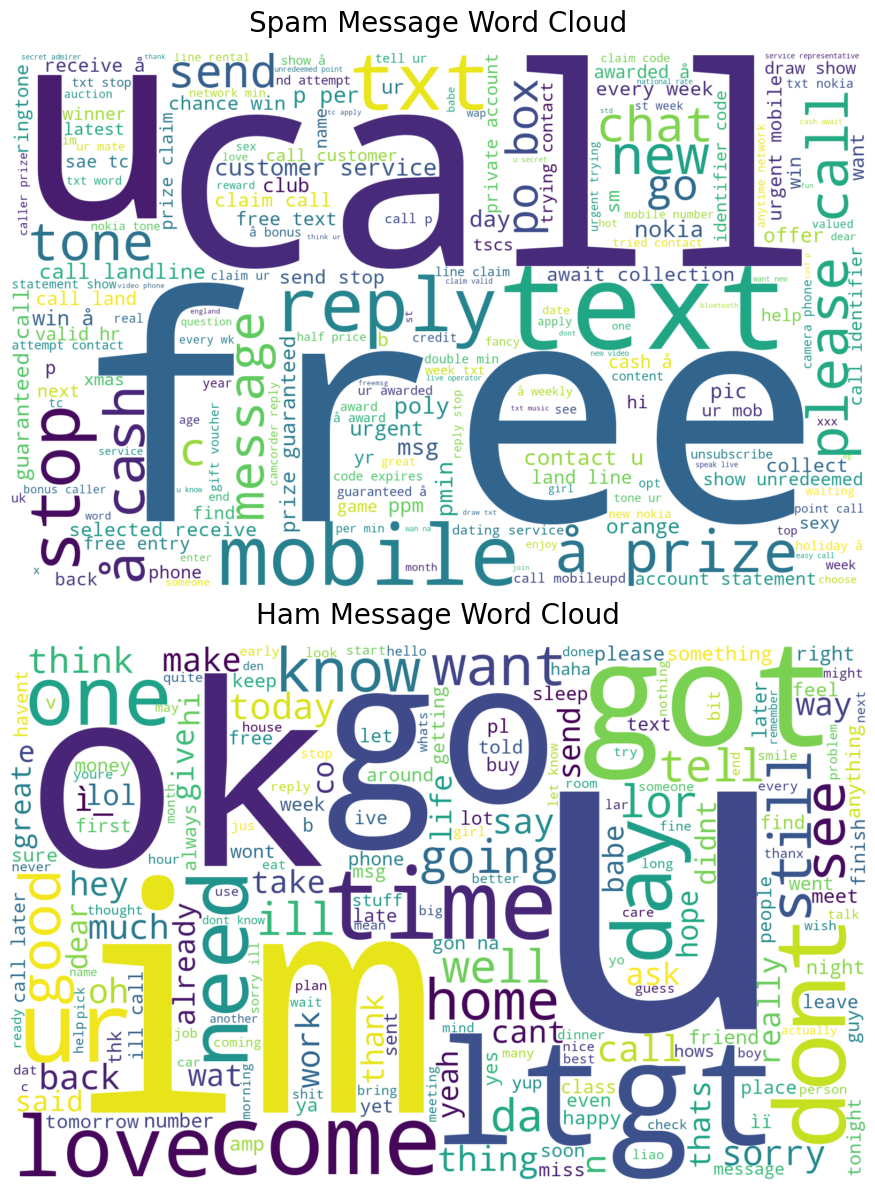

In [30]:
# Word Cloud Visualization
plt.figure(figsize=(15, 12))

# Plot Spam Word Cloud
plt.subplot(2, 1, 1)
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.title('Spam Message Word Cloud', 
          fontsize=20,                
          pad=15)                
plt.axis('off')

# Plot Ham Word Cloud
plt.subplot(2, 1, 2)
plt.imshow(ham_wordcloud, interpolation='bilinear')
plt.title('Ham Message Word Cloud', 
          fontsize=20, 
          pad=15)
plt.axis('off')

plt.tight_layout()
plt.show()

In [31]:
# Vectorization


,Category,Messages,url_count,email_count
0,0,go jurong point crazy available bugis n great ...,0,0
1,0,ok lar joking wif u oni,0,0
2,1,free entry wkly comp win fa cup final tkts st ...,0,0
3,0,u dun say early hor u c already say,0,0
4,0,nah dont think go usf life around though,0,0
5,1,freemsg hey darling week word back id like fun...,0,0
6,0,even brother like speak treat like aid patent,0,0
7,0,per request melle melle oru minnaminunginte nu...,0,0
8,1,winner valued network customer selected receiv...,0,0
9,1,mobile month u r entitled update latest colour...,0,0


In [ ]:
# Checking for presence of class imbalance
count_category = df['Category'].value_counts()
count_category

In [ ]:
# Graphical Representation
plt.bar(count_category.index, count_category.values, color=['teal', 'orange'])
plt.title("Ham vs Spam Counts")
plt.xlabel("Category")
plt.ylabel("Total Count of Messages")

In [ ]:
# train test split

In [ ]:
#
#model selection 
#evaluation metrics (confusion, roc curve, f1score,recall)
# comparison betwn two  

In [ ]:
# TF-IDF - Mathmatical question
# shailshree.shah@islingtoncollege.edu.np